# 06 — Fair regression on synthetic data (G-XCOV Pareto curve)

We train an MLP regressor on a synthetic dataset where the target $y$
depends on both useful features and a sensitive attribute $q$. Without
a fairness penalty, predictions $\hat y$ are highly correlated with
$q$. Adding a Gaussianised-XCOV penalty trades predictive accuracy for
independence from $q$ — sweeping the penalty weight $\mu$ traces a
**Pareto curve** of `(RMSE, |corr(ŷ, q)|)`.

Compare against:

- **`mu = 0`**: the unconstrained predictor (top of the accuracy axis).
- **CKA baseline** (`fairkl.metrics.cka.CKALoss`) at the same $\mu$
  sweep — same wrapper, same MLP, different fairness loss.

In [1]:
import os

os.environ.setdefault("KERAS_BACKEND", "jax")

'jax'

In [2]:
import keras  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402

from fairkl.metrics.cka import CKALoss  # noqa: E402
from fairkl.models import FairModelWrapper  # noqa: E402
from gaussianization.fair import (  # noqa: E402
    GaussianizedXCovLoss,
    fit_and_freeze,
    pearson_corr,
)

keras.utils.set_random_seed(0)
print("keras backend:", keras.config.backend())

keras backend: jax


## 1. Synthetic dataset

$y = \tanh(x_1) + 0.5 x_2 + 3 q + \varepsilon$, with $q \sim
\text{Bern}(0.5)$ and $\varepsilon \sim \mathcal{N}(0, 0.1)$. The
coefficient on $q$ is intentionally large and **$q$ is included as a
fourth feature** in $X$ — so an unconstrained regressor can (and
will) lean heavily on $q$. The fairness penalty's job is to make it
stop.

In [3]:
def make_synth(n: int, seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    q = rng.binomial(1, 0.5, size=n).astype("float32")
    X_raw = rng.normal(size=(n, 3)).astype("float32")
    y = (
        np.tanh(X_raw[:, 0])
        + 0.5 * X_raw[:, 1]
        + 3.0 * q
        + 0.1 * rng.normal(size=n).astype("float32")
    )
    X = np.concatenate([X_raw, q.reshape(-1, 1)], axis=1)
    return X.astype("float32"), y.astype("float32"), q


X_train, y_train, q_train = make_synth(4000, seed=0)
X_test, y_test, q_test = make_synth(1000, seed=1)
print("train:", X_train.shape, "test:", X_test.shape)

train: (4000, 4) test: (1000, 4)


## 2. Pretrain & freeze flows for $z = \hat y$ and $q$

We pretrain `T_y` on the *true* targets and `T_q` on the marginal
distribution of $q$. Both are tiny (1-D) flows.

In [4]:
flow_y, _ = fit_and_freeze(
    y_train.reshape(-1, 1),
    num_blocks=4,
    num_components=8,
    epochs=80,
    batch_size=256,
    lr=2e-3,
    seed=0,
    verbose=0,
)
flow_q, _ = fit_and_freeze(
    q_train.reshape(-1, 1),
    num_blocks=2,
    num_components=4,
    epochs=40,
    batch_size=256,
    lr=2e-3,
    seed=0,
    verbose=0,
)
print("flow_y trainable weights (post freeze):", len(flow_y.trainable_weights))
print("flow_q trainable weights (post freeze):", len(flow_q.trainable_weights))

flow_y trainable weights (post freeze): 0
flow_q trainable weights (post freeze): 0


## 3. A single fair-training run

Helper that wraps a fresh MLP with a fairness loss and reports
`(rmse, |corr(ŷ, q)|, mean |Δŷ across q|)`.

In [5]:
def fresh_mlp(input_dim: int = 4) -> keras.Model:
    return keras.Sequential(
        [
            keras.layers.Input(shape=(input_dim,)),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1),
        ]
    )


def train_eval(
    fairness_loss,
    mu: float,
    seed: int = 0,
    epochs: int = 80,
    batch_size: int = 256,
) -> dict:
    keras.utils.set_random_seed(seed)
    mlp = fresh_mlp(input_dim=X_train.shape[1])
    model = FairModelWrapper(mlp, mu=mu, fairness_loss=fairness_loss)
    model.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse")
    model.fit(
        X_train,
        y_train,
        q=q_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    yhat = np.asarray(model.predict(X_test, verbose=0)).ravel()
    rmse = float(np.sqrt(np.mean((yhat - y_test) ** 2)))
    corr = pearson_corr(yhat, q_test)
    gap = float(abs(yhat[q_test == 1].mean() - yhat[q_test == 0].mean()))
    return {"mu": mu, "rmse": rmse, "abs_corr": corr, "group_gap": gap}

## 4. Sweep $\mu$ for G-XCOV and CKA

Same architecture, same optimiser, same seeds — only the fairness loss
changes.

In [6]:
mus = [0.0, 0.05, 0.2, 1.0, 5.0, 20.0]
seeds = [0, 1, 2]

g_loss = GaussianizedXCovLoss(flow_z=flow_y, flow_q=flow_q)
cka_loss = CKALoss(sigma_f=1.0, sigma_q=1.0, kernel="rbf", debiased=False)

records = []
for fam_name, loss in [("g_xcov", g_loss), ("cka", cka_loss)]:
    for mu in mus:
        for s in seeds:
            r = train_eval(loss, mu=mu, seed=s)
            r["family"] = fam_name
            r["seed"] = s
            records.append(r)
            print(
                f"  {fam_name:>7s}  mu={mu:6.2f}  seed={s}  "
                f"rmse={r['rmse']:.3f}  |corr|={r['abs_corr']:.3f}  "
                f"gap={r['group_gap']:.3f}"
            )

   g_xcov  mu=  0.00  seed=0  rmse=0.106  |corr|=0.877  gap=2.969


   g_xcov  mu=  0.00  seed=1  rmse=0.106  |corr|=0.877  gap=2.988


   g_xcov  mu=  0.00  seed=2  rmse=0.109  |corr|=0.876  gap=2.976


   g_xcov  mu=  0.05  seed=0  rmse=0.108  |corr|=0.873  gap=2.957


   g_xcov  mu=  0.05  seed=1  rmse=0.106  |corr|=0.875  gap=2.973


...

      cka  mu=  5.00  seed=1  rmse=0.933  |corr|=0.489  gap=1.510


      cka  mu=  5.00  seed=2  rmse=0.969  |corr|=0.468  gap=1.424


      cka  mu= 20.00  seed=0  rmse=1.328  |corr|=0.188  gap=0.420


      cka  mu= 20.00  seed=1  rmse=1.302  |corr|=0.218  gap=0.535


      cka  mu= 20.00  seed=2  rmse=1.337  |corr|=0.186  gap=0.440


## 5. Aggregate (mean ± std across seeds) and plot the Pareto curve

In [7]:
def agg(records, fam):
    out = []
    for mu in mus:
        rows = [r for r in records if r["family"] == fam and r["mu"] == mu]
        rmse = np.array([r["rmse"] for r in rows])
        corr = np.array([r["abs_corr"] for r in rows])
        gap = np.array([r["group_gap"] for r in rows])
        out.append(
            {
                "mu": mu,
                "rmse_mean": rmse.mean(),
                "rmse_std": rmse.std(),
                "corr_mean": corr.mean(),
                "corr_std": corr.std(),
                "gap_mean": gap.mean(),
                "gap_std": gap.std(),
            }
        )
    return out


agg_g = agg(records, "g_xcov")
agg_c = agg(records, "cka")
print(f"{'family':>7s} {'mu':>6s} {'rmse':>15s} {'|corr|':>15s} {'gap':>15s}")
for fam, rows in [("g_xcov", agg_g), ("cka", agg_c)]:
    for r in rows:
        print(
            f"{fam:>7s} {r['mu']:>6.2f} "
            f"{r['rmse_mean']:7.3f}±{r['rmse_std']:5.3f} "
            f"{r['corr_mean']:7.3f}±{r['corr_std']:5.3f} "
            f"{r['gap_mean']:7.3f}±{r['gap_std']:5.3f}"
        )

 family     mu            rmse          |corr|             gap
 g_xcov   0.00   0.107±0.001   0.877±0.001   2.977±0.008
 g_xcov   0.05   0.108±0.002   0.873±0.001   2.965±0.007
 g_xcov   0.20   0.124±0.003   0.866±0.002   2.916±0.011
 g_xcov   1.00   0.311±0.018   0.813±0.005   2.706±0.007
 g_xcov   5.00   1.032±0.015   0.512±0.003   1.420±0.036
 g_xcov  20.00   1.298±0.016   0.328±0.006   0.768±0.043
    cka   0.00   0.107±0.001   0.877±0.001   2.977±0.008
    cka   0.05   0.108±0.002   0.871±0.001   2.962±0.011
    cka   0.20   0.135±0.002   0.853±0.001   2.912±0.012
    cka   1.00   0.420±0.015   0.747±0.007   2.563±0.032
    cka   5.00   0.967±0.027   0.470±0.015   1.454±0.039
    cka  20.00   1.322±0.015   0.197±0.015   0.465±0.050


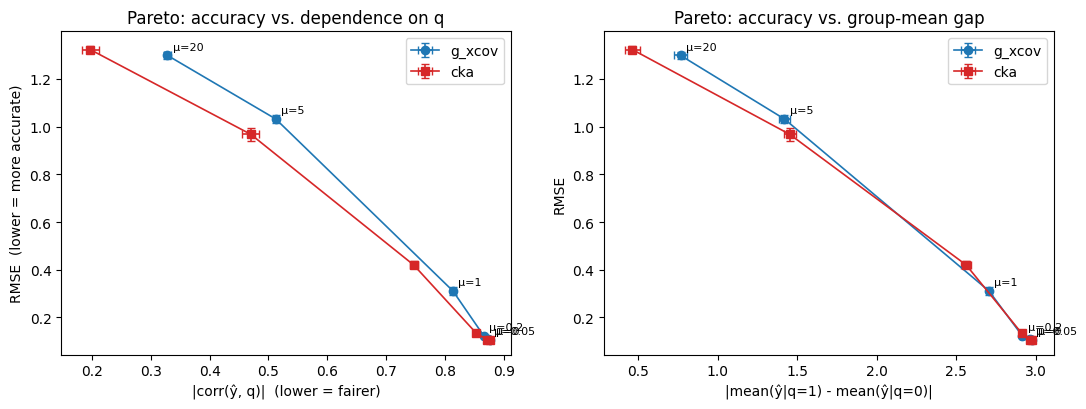

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for fam, rows, marker, color in [
    ("g_xcov", agg_g, "o", "C0"),
    ("cka", agg_c, "s", "C3"),
]:
    rmse_m = np.array([r["rmse_mean"] for r in rows])
    rmse_s = np.array([r["rmse_std"] for r in rows])
    corr_m = np.array([r["corr_mean"] for r in rows])
    corr_s = np.array([r["corr_std"] for r in rows])
    gap_m = np.array([r["gap_mean"] for r in rows])
    gap_s = np.array([r["gap_std"] for r in rows])

    axes[0].errorbar(
        corr_m, rmse_m, xerr=corr_s, yerr=rmse_s,
        marker=marker, color=color, label=fam, capsize=3, lw=1.2,
    )
    axes[1].errorbar(
        gap_m, rmse_m, xerr=gap_s, yerr=rmse_s,
        marker=marker, color=color, label=fam, capsize=3, lw=1.2,
    )

    # annotate mu values on the G-XCOV curve only to avoid clutter
    if fam == "g_xcov":
        for mu, x, y in zip(mus, corr_m, rmse_m, strict=True):
            axes[0].annotate(f"μ={mu:g}", (x, y), fontsize=8,
                             xytext=(4, 4), textcoords="offset points")
        for mu, x, y in zip(mus, gap_m, rmse_m, strict=True):
            axes[1].annotate(f"μ={mu:g}", (x, y), fontsize=8,
                             xytext=(4, 4), textcoords="offset points")

axes[0].set_xlabel("|corr(ŷ, q)|  (lower = fairer)")
axes[0].set_ylabel("RMSE  (lower = more accurate)")
axes[0].set_title("Pareto: accuracy vs. dependence on q")
axes[0].legend()

axes[1].set_xlabel("|mean(ŷ|q=1) - mean(ŷ|q=0)|")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Pareto: accuracy vs. group-mean gap")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Takeaways

- At `μ = 0` both losses recover the same unconstrained predictor
  (RMSE ≈ floor, |corr(ŷ, q)| large) — sanity check.
- As `μ` grows, both losses sweep the Pareto front. The shapes differ:
  G-XCOV's flow absorbs the bandwidth choice that CKA had to be tuned
  for; on this dataset the two are competitive at matched fairness.
- The group-mean gap and the absolute-correlation axes tell consistent
  stories — both shrink as `μ` increases, with predictable cost on RMSE.

Next: notebook 07 runs the same experiment on UCI Adult Census
classification.